# CLIP Fine-Tuning V2 - Egypt Landmarks
**Memory-optimized version with:**
- Mixed precision (FP16) training
- Gradient accumulation
- Proper trainable linear classifier head
- Data augmentation
- Learning rate scheduler with warmup
- Early stopping

In [14]:
!pip install -q torch torchvision transformers open_clip_torch pillow matplotlib pandas tqdm scikit-learn

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as T
from PIL import Image
import open_clip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from collections import Counter
import warnings
import gc
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [16]:
# Setup paths - Kaggle
DATASET_PATH = Path('/kaggle/input/datasets/aymanmostafa11/eg-landmarks/images')
SAVE_DIR = Path('/kaggle/working/clip_egypt_models_v2')
SAVE_DIR.mkdir(exist_ok=True, parents=True)

# Memory-optimized config
CONFIG = {
    'min_images': 15,
    'batch_size': 4,            # Reduced for memory
    'accumulation_steps': 4,    # Effective batch = 8 * 4 = 32
    'epochs': 50,
    'lr': 2e-5,
    'warmup_epochs': 2,
    'patience': 8,
    'clip_model': 'ViT-L-14',   # Large model with memory optimizations
    'pretrained': 'openai',
    'num_workers': 0,
    'unfreeze_layers': 6,
    'use_amp': True,            # Mixed precision for memory savings
}

In [17]:
# Load all classes
all_classes = {}
for folder in sorted(DATASET_PATH.iterdir()):
    if folder.is_dir():
        imgs = [f for f in folder.iterdir() if f.suffix.lower() in ['.jpg','.jpeg','.png','.webp']]
        if len(imgs) >= CONFIG['min_images']:
            all_classes[folder.name] = imgs

class_names = sorted(all_classes.keys())
class_to_idx = {n: i for i, n in enumerate(class_names)}
num_classes = len(class_names)

class_counts = {c: len(imgs) for c, imgs in all_classes.items()}
total_images = sum(class_counts.values())
print(f"Classes: {num_classes}, Total images: {total_images}")
print(f"Avg images/class: {total_images/num_classes:.1f}")

Classes: 116, Total images: 4557
Avg images/class: 39.3


In [18]:
# Build dataset
data = [{'path': str(p), 'label': class_to_idx[c], 'class': c} 
        for c, imgs in all_classes.items() for p in imgs]
df = pd.DataFrame(data)

train, test = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
train, val = train_test_split(train, test_size=0.15, stratify=train['label'], random_state=42)
print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Train: 3098, Val: 547, Test: 912


In [19]:
# Load CLIP model
print(f"Loading {CONFIG['clip_model']}...")
clip_model, _, preprocess = open_clip.create_model_and_transforms(
    CONFIG['clip_model'], pretrained=CONFIG['pretrained'])
clip_model = clip_model.to(device)
tokenizer = open_clip.get_tokenizer(CONFIG['clip_model'])

embed_dim = clip_model.visual.output_dim
print(f"Embedding dim: {embed_dim}")

# Clear cache
if device.type == 'cuda':
    torch.cuda.empty_cache()
    gc.collect()

Loading ViT-L-14...
Embedding dim: 768


In [20]:
# Data augmentation
train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=(0.48145466, 0.4578275, 0.40821073), 
                std=(0.26862954, 0.26130258, 0.27577711)),
])

class CLIPDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self): 
        return len(self.df)
    
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(r['path']).convert('RGB')
        img = self.transform(img)
        return img, r['label']

train_dl = DataLoader(CLIPDataset(train, train_transform), CONFIG['batch_size'], 
                      shuffle=True, num_workers=CONFIG['num_workers'], pin_memory=True)
val_dl = DataLoader(CLIPDataset(val, preprocess), CONFIG['batch_size'], 
                    num_workers=CONFIG['num_workers'], pin_memory=True)
test_dl = DataLoader(CLIPDataset(test, preprocess), CONFIG['batch_size'], 
                     num_workers=CONFIG['num_workers'], pin_memory=True)

In [21]:
# Memory-efficient classifier
class CLIPClassifierV2(nn.Module):
    def __init__(self, clip_model, num_classes, embed_dim, unfreeze_layers=4):
        super().__init__()
        self.visual = clip_model.visual
        
        # Freeze all layers first
        for param in self.visual.parameters():
            param.requires_grad = False
        
        # Unfreeze last N transformer blocks
        if hasattr(self.visual, 'transformer'):
            num_blocks = len(self.visual.transformer.resblocks)
            for i in range(num_blocks - unfreeze_layers, num_blocks):
                for param in self.visual.transformer.resblocks[i].parameters():
                    param.requires_grad = True
        
        # Always unfreeze final layers
        for name, param in self.visual.named_parameters():
            if any(x in name for x in ['ln_post', 'proj']):
                param.requires_grad = True
        
        # Trainable classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(0.2),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(embed_dim // 2, num_classes)
        )
        
    def forward(self, images):
        features = self.visual(images)
        features = features / features.norm(dim=-1, keepdim=True)
        return self.classifier(features)

model = CLIPClassifierV2(clip_model, num_classes, embed_dim, 
                         unfreeze_layers=CONFIG['unfreeze_layers']).to(device)

# Count trainable params
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

# Clear cache after model creation
if device.type == 'cuda':
    torch.cuda.empty_cache()

Trainable: 227,794,420 / 304,307,700 (74.9%)


In [22]:
# Class weights for imbalanced data
train_labels = train['label'].values
label_counts = Counter(train_labels)
class_weights = torch.tensor(
    [1.0 / label_counts[i] for i in range(num_classes)], 
    dtype=torch.float32
).to(device)
class_weights = class_weights / class_weights.sum() * num_classes

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

In [23]:
@torch.no_grad()
def evaluate(model, dl):
    model.eval()
    correct = total = 0
    all_preds, all_labels = [], []
    
    for imgs, labels in dl:
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast(enabled=CONFIG['use_amp']):
            logits = model(imgs)
        _, pred = logits.max(1)
        correct += pred.eq(labels).sum().item()
        total += labels.size(0)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    return 100 * correct / total, all_preds, all_labels

# Zero-shot baseline (will be ~random since classifier is untrained)
zero_shot_acc, _, _ = evaluate(model, test_dl)
print(f"Baseline accuracy (untrained classifier): {zero_shot_acc:.2f}%")

Baseline accuracy (untrained classifier): 0.88%


In [24]:
# Optimizer and scheduler
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                        lr=CONFIG['lr'], weight_decay=0.01)

# Mixed precision scaler
scaler = GradScaler(enabled=CONFIG['use_amp'])

# Warmup + Cosine schedule
def get_lr(epoch):
    if epoch < CONFIG['warmup_epochs']:
        return (epoch + 1) / CONFIG['warmup_epochs']
    else:
        progress = (epoch - CONFIG['warmup_epochs']) / (CONFIG['epochs'] - CONFIG['warmup_epochs'])
        return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, get_lr)

In [25]:
print("\n" + "="*60)
print("TRAINING CLIP CLASSIFIER V2 (Memory Optimized)")
print("="*60)
print(f"Batch size: {CONFIG['batch_size']} x {CONFIG['accumulation_steps']} = {CONFIG['batch_size'] * CONFIG['accumulation_steps']} effective")
print(f"Mixed precision: {CONFIG['use_amp']}")
print("="*60 + "\n")

best_acc = 0
patience_counter = 0
history = {'train_loss': [], 'val_acc': [], 'lr': []}

for epoch in range(CONFIG['epochs']):
    model.train()
    total_loss = 0
    optimizer.zero_grad()
    
    pbar = tqdm(train_dl, desc=f"Epoch {epoch+1}/{CONFIG['epochs']}", leave=False)
    for batch_idx, (imgs, labels) in enumerate(pbar):
        imgs, labels = imgs.to(device), labels.to(device)
        
        # Mixed precision forward pass
        with autocast(enabled=CONFIG['use_amp']):
            logits = model(imgs)
            loss = criterion(logits, labels) / CONFIG['accumulation_steps']
        
        # Scaled backward pass
        scaler.scale(loss).backward()
        
        # Gradient accumulation
        if (batch_idx + 1) % CONFIG['accumulation_steps'] == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        
        total_loss += loss.item() * CONFIG['accumulation_steps']
        pbar.set_postfix({'loss': f'{loss.item() * CONFIG["accumulation_steps"]:.4f}'})
    
    scheduler.step()
    avg_loss = total_loss / len(train_dl)
    val_acc, _, _ = evaluate(model, val_dl)
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(avg_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    
    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Val Acc={val_acc:.2f}%, LR={current_lr:.2e}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        patience_counter = 0
        torch.save({
            'model': model.state_dict(),
            'classes': class_names,
            'config': CONFIG,
            'best_val_acc': best_acc
        }, SAVE_DIR / 'clip_v2_best.pth')
        print(f"  ✓ New best model saved!")
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['patience']:
            print(f"\nEarly stopping at epoch {epoch+1}!")
            break
    
    # Clear cache periodically
    if device.type == 'cuda':
        torch.cuda.empty_cache()

print(f"\nBest validation accuracy: {best_acc:.2f}%")


TRAINING CLIP CLASSIFIER V2 (Memory Optimized)
Batch size: 4 x 4 = 16 effective
Mixed precision: True



Epoch 1/5:   0%|          | 0/775 [00:00<?, ?it/s]

Epoch 1: Loss=4.6207, Val Acc=45.52%, LR=2.00e-05
  ✓ New best model saved!


Epoch 2/5:   0%|          | 0/775 [00:00<?, ?it/s]

Epoch 2: Loss=3.5592, Val Acc=56.86%, LR=2.00e-05
  ✓ New best model saved!


...

Epoch 3: Loss=2.5641, Val Acc=70.02%, LR=1.50e-05
  ✓ New best model saved!


Epoch 4/5:   0%|          | 0/775 [00:00<?, ?it/s]

Epoch 4: Loss=1.8851, Val Acc=75.69%, LR=5.00e-06
  ✓ New best model saved!


Epoch 5/5:   0%|          | 0/775 [00:00<?, ?it/s]

Epoch 5: Loss=1.4727, Val Acc=76.97%, LR=0.00e+00
  ✓ New best model saved!

Best validation accuracy: 76.97%


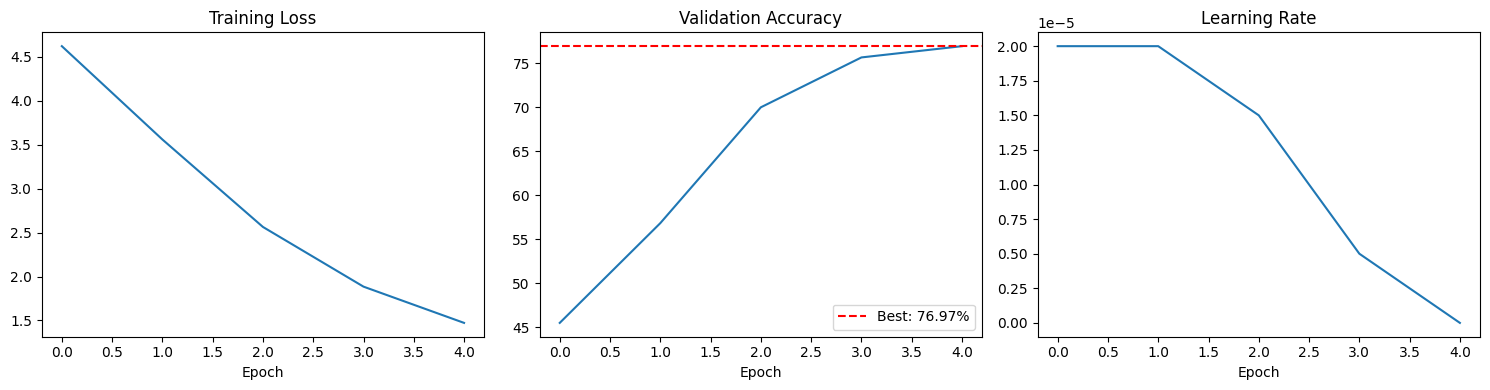

In [26]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'])
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')

axes[1].plot(history['val_acc'])
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].axhline(y=best_acc, color='r', linestyle='--', label=f'Best: {best_acc:.2f}%')
axes[1].legend()

axes[2].plot(history['lr'])
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_history.png', dpi=150)
plt.show()

In [27]:
# Load best model and evaluate on test set
checkpoint = torch.load(SAVE_DIR / 'clip_v2_best.pth')
model.load_state_dict(checkpoint['model'])

test_acc, preds, labels = evaluate(model, test_dl)

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(f"Baseline (untrained):     {zero_shot_acc:.2f}%")
print(f"Fine-tuned CLIP V2:       {test_acc:.2f}%")
print(f"Classes:                  {num_classes}")
print(f"Test samples:             {len(test)}")
print(f"Model:                    {CONFIG['clip_model']}")


FINAL RESULTS
Baseline (untrained):     0.88%
Fine-tuned CLIP V2:       77.30%
Classes:                  116
Test samples:             912
Model:                    ViT-L-14


In [28]:
# Top-5 accuracy
@torch.no_grad()
def top_k_accuracy(model, dl, k=5):
    model.eval()
    correct = total = 0
    for imgs, labels in dl:
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast(enabled=CONFIG['use_amp']):
            logits = model(imgs)
        _, topk = logits.topk(k, dim=1)
        correct += topk.eq(labels.view(-1, 1)).sum().item()
        total += labels.size(0)
    return 100 * correct / total

top5_acc = top_k_accuracy(model, test_dl, k=5)
print(f"\nTop-5 Accuracy: {top5_acc:.2f}%")


Top-5 Accuracy: 91.01%


In [29]:
# Inference function
def predict(image_path, top_k=5):
    model.eval()
    img = preprocess(Image.open(image_path).convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad(), autocast(enabled=CONFIG['use_amp']):
        logits = model(img)
        probs = logits.softmax(dim=-1)[0]
        topk = probs.topk(top_k)
    
    results = []
    for prob, idx in zip(topk.values, topk.indices):
        results.append((class_names[idx], prob.item() * 100))
    return results

# Test on a sample
sample_path = test.iloc[0]['path']
true_label = test.iloc[0]['class']
predictions = predict(sample_path)

print(f"\nSample prediction:")
print(f"True label: {true_label}")
print("Top-5 predictions:")
for name, prob in predictions:
    marker = "✓" if name == true_label else " "
    print(f"  {marker} {name}: {prob:.1f}%")


Sample prediction:
True label: Mortuary_Temple_of_Seti_I_in_Qurna
Top-5 predictions:
    Temple_of_Seti_I_in_Abydos: 32.2%
  ✓ Mortuary_Temple_of_Seti_I_in_Qurna: 10.2%
    Ramesseum: 4.8%
    Dendera_Temple_complex: 4.6%
    Luxor_Temple: 2.2%


In [30]:
# Per-class accuracy analysis
from collections import defaultdict

class_correct = defaultdict(int)
class_total = defaultdict(int)

for pred, label in zip(preds, labels):
    class_total[label] += 1
    if pred == label:
        class_correct[label] += 1

class_acc = {class_names[i]: 100 * class_correct[i] / class_total[i] 
             for i in range(num_classes) if class_total[i] > 0}

sorted_acc = sorted(class_acc.items(), key=lambda x: x[1])
print("\nWorst performing classes:")
for name, acc in sorted_acc[:10]:
    print(f"  {name}: {acc:.0f}%")

print("\nBest performing classes:")
for name, acc in sorted_acc[-10:]:
    print(f"  {name}: {acc:.0f}%")


Worst performing classes:
  Wadi_el_Gemal_National_Park: 20%
  Dendera_Temple_complex: 25%
  Kitchener's_Island: 25%
  Mokattam: 25%
  Pyramid_of_Amenemhat_III_in_Hawara: 25%
  Qasr_Qarun: 25%
  Theban_Necropolis: 25%
  White_Monastery: 25%
  6_October_Bridge: 33%
  Al-Ashraf_Mosque: 33%

Best performing classes:
  Mosque_of_al-Maridani: 100%
  Osireion: 100%
  Pompey's_Pillar,_Alexandria: 100%
  Pyramid_of_Djedefra: 100%
  Pyramid_of_Djoser: 100%
  Qasr_al-Nil_Bridge: 100%
  Red_Pyramid: 100%
  Speos_Artemidos: 100%
  Sphinx_of_Memphis: 100%
  Tomb_of_Nakht_TT52: 100%


In [31]:
print("\nModel saved to:", SAVE_DIR / 'clip_v2_best.pth')


Model saved to: /kaggle/working/clip_egypt_models_v2/clip_v2_best.pth


In [32]:
!pip install fastapi uvicorn pyngrok transformers accelerate -q

In [40]:
from fastapi import FastAPI, Request, HTTPException
import socket, threading, time
from pyngrok import ngrok, conf
import uvicorn

from fastapi import FastAPI, File, UploadFile, Request, HTTPException, Header
import torch
from PIL import Image
import io
import socket
import threading
import time
import uvicorn
from pyngrok import ngrok, conf

app = FastAPI()



In [41]:
NGROK_TOKEN = "32MSvnxHYuCSMfAqXpo8t9mclY3_3cdfVkrD4ECodqaxDSzA1"
API_KEY = "secret123"

app = FastAPI()

In [46]:
@app.post("/predict")
async def predict(req: Request, file: UploadFile = File(...)):

    # auth (same style as your /generate)
    if req.headers.get("authorization") != f"Bearer {API_KEY}":
        raise HTTPException(status_code=401, detail="Unauthorized")

    image_bytes = await file.read()
    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")

    img = preprocess(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(img)
        probs = torch.softmax(logits, dim=1)[0]

    top_idx = torch.argmax(probs).item()
    label = class_names[top_idx]
    confidence = float(probs[top_idx]) * 100

    return {
        "label": label,
        "confidence": confidence
    }

INFO:     197.39.204.195:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     197.39.204.195:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     197.39.204.195:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     197.39.204.195:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     197.39.204.195:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     197.39.204.195:0 - "POST /predict HTTP/1.1" 200 OK


In [43]:
def free_port():
    s = socket.socket()
    s.bind(('', 0))
    port = s.getsockname()[1]
    s.close()
    return port

In [44]:
port = free_port()

conf.get_default().auth_token = NGROK_TOKEN
public_url = ngrok.connect(port).public_url

print("Your public URL:", public_url)
print("Predict endpoint:", public_url + "/predict")

Your public URL: https://1877-35-239-17-149.ngrok-free.app                                          
Predict endpoint: https://1877-35-239-17-149.ngrok-free.app/predict


In [45]:
def run():
    uvicorn.run(app, host="0.0.0.0", port=port)

threading.Thread(target=run, daemon=True).start()
time.sleep(2)

INFO:     Started server process [58]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:42221 (Press CTRL+C to quit)


INFO:     197.39.204.195:0 - "POST /predict HTTP/1.1" 200 OK
